# Dental Radiography: Custom Grid Detector ve YOLO26s Karşılaştırması

Bu notebook, dental radyografi görüntülerindeki dört nesne sınıfını tespit etmek için iki yaklaşımı inceler:

1. **Sıfırdan geliştirilen ResNet50 tabanlı grid detector**
2. **Pretrained YOLO26s detector**

Sınıflar:

- `Cavity`
- `Fillings`
- `Impacted Tooth`
- `Implant`

Notebook'un amacı yalnızca yüksek skor elde etmek değil; object detection hattındaki veri hazırlama, target encoding, loss, metrik ve model tasarımı adımlarını anlaşılır biçimde göstermektir.

> **Önemli karşılaştırma notu:** Custom modelde kullanılan `mean aligned box IoU`, YOLO'nun `mAP50` veya `mAP50-95` metriğiyle aynı değildir. Bu nedenle sayılar doğrudan eşit metriklermiş gibi karşılaştırılmamalıdır.

## 1. Kurulum ve ortak ayarlar

Kaggle ortamında gerekli paketler çoğunlukla hazır gelir. Aşağıdaki hücre eksik paketleri kurar.

In [20]:
%pip install -q torchmetrics ultralytics pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 30.6 MB/s eta 0:00:0000:01
Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import random
import shutil
import yaml

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from IPython.display import display
from matplotlib.patches import Rectangle

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import tv_tensors
from torchvision.transforms import v2
from torchvision.models import resnet50, ResNet50_Weights
from torchvision.ops import box_convert, box_iou

from torchmetrics.classification import (
    BinaryPrecision,
    BinaryRecall,
    BinaryF1Score,
    MulticlassAccuracy,
)
from torchmetrics.aggregation import MeanMetric

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DATA_ROOT = Path("/kaggle/input/datasets/imtkaggleteam/dental-radiography")
WORK_ROOT = Path("/kaggle/working")
YOLO_ROOT = WORK_ROOT / "Yolo_format"

CLASS_TO_ID = {
    "Cavity": 0,
    "Fillings": 1,
    "Impacted Tooth": 2,
    "Implant": 3,
}

ID_TO_CLASS = {class_id: name for name, class_id in CLASS_TO_ID.items()}
NUM_CLASSES = len(CLASS_TO_ID)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", DEVICE)
print("Dataset:", DATA_ROOT)
print("Classes:", CLASS_TO_ID)

Device: cuda
Dataset: /kaggle/input/datasets/imtkaggleteam/dental-radiography
Classes: {'Cavity': 0, 'Fillings': 1, 'Impacted Tooth': 2, 'Implant': 3}


## 2. Veri setini yükleme

Her split klasöründe bir `_annotations.csv` dosyası bulunur. CSV'deki her satır tek bir bounding box'ı temsil eder. Aynı görüntü birden fazla nesne içeriyorsa dosya adı birden fazla satırda görünür.

In [3]:
def load_annotations(data_root: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    frames = {}

    for split in ("train", "valid", "test"):
        csv_path = data_root / split / "_annotations.csv"

        if not csv_path.exists():
            raise FileNotFoundError(f"Annotation dosyası bulunamadı: {csv_path}")

        split_df = pd.read_csv(csv_path)
        split_df["split"] = split
        frames[split] = split_df

    all_df = pd.concat(
        [frames["train"], frames["valid"], frames["test"]],
        ignore_index=True,
    )

    return frames["train"], frames["valid"], frames["test"], all_df


raw_train_df, raw_valid_df, raw_test_df, raw_df = load_annotations(DATA_ROOT)

display(raw_df.head())
print("\nAnnotation satır sayıları:")
print(raw_df.groupby("split").size())
print("\nBenzersiz görüntü sayıları:")
print(raw_df.groupby("split")["filename"].nunique())

,filename,width,height,class,xmin,ymin,xmax,ymax,split
0,0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg,512,256,Implant,175,116,206,153,train
1,0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg,512,256,Fillings,170,109,189,133,train
2,0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg,512,256,Implant,221,124,257,178,train
3,0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg,512,256,Implant,302,126,329,175,train
4,0674_jpg.rf.e02a155a0c135687b9301ff9a20d220a.jpg,512,256,Implant,335,114,360,154,train



Annotation satır sayıları:
split
test      473
train    8030
valid     780
dtype: int64

Benzersiz görüntü sayıları:
split
test       73
train    1075
valid     121
Name: filename, dtype: int64


## 3. Veri kalite kontrolleri

Object detection veri setinde yalnızca null kontrolü yeterli değildir. Bounding box koordinatlarının da şu koşulları sağlaması gerekir:

- `0 ≤ xmin < xmax ≤ image_width`
- `0 ≤ ymin < ymax ≤ image_height`

Geçersiz kutular eğitim sırasında hatalı target üretebilir.

In [4]:
REQUIRED_COLUMNS = {
    "filename", "width", "height", "class",
    "xmin", "ymin", "xmax", "ymax", "split",
}

missing_columns = REQUIRED_COLUMNS - set(raw_df.columns)
if missing_columns:
    raise ValueError(f"Eksik sütunlar: {missing_columns}")

print("Null değer sayıları:")
display(raw_df.isna().sum().to_frame("null_count"))

valid_x = (
    (raw_df["xmin"] >= 0)
    & (raw_df["xmin"] < raw_df["xmax"])
    & (raw_df["xmax"] <= raw_df["width"])
)

valid_y = (
    (raw_df["ymin"] >= 0)
    & (raw_df["ymin"] < raw_df["ymax"])
    & (raw_df["ymax"] <= raw_df["height"])
)

valid_class = raw_df["class"].isin(CLASS_TO_ID)

invalid_mask = ~(valid_x & valid_y & valid_class)
invalid_boxes = raw_df.loc[invalid_mask].copy()

print("Geçersiz annotation sayısı:", len(invalid_boxes))
display(invalid_boxes)

clean_df = raw_df.loc[~invalid_mask].copy().reset_index(drop=True)
clean_df["class_id"] = clean_df["class"].map(CLASS_TO_ID).astype("int64")

print("Temiz annotation sayısı:", len(clean_df))

Null değer sayıları:


,null_count
filename,0
width,0
height,0
class,0
xmin,0
ymin,0
xmax,0
ymax,0
split,0


Geçersiz annotation sayısı: 3


,filename,width,height,class,xmin,ymin,xmax,ymax,split
1095,0974_jpg.rf.ff31d35aecfa18f7a3bb61736cb40dcf.jpg,512,256,Fillings,374,117,376,117,train
1385,0974_jpg.rf.08aa86b32941f04af43189a63b4f6683.jpg,512,256,Fillings,136,139,138,139,train
1668,0974_jpg.rf.1106191cfb2fa2d640fa75593eeb8122.jpg,512,256,Fillings,136,117,138,117,train


Temiz annotation sayısı: 9280


### 3.1 Sınıf dağılımı ve görüntü başına nesne sayısı

Veri seti sınıf açısından dengesizdir. Özellikle `Fillings` sınıfı çoğunluktadır; `Cavity` ve `Impacted Tooth` daha az örnek içerir. Bu durum genel metriklerin çoğunluk sınıfı tarafından yükseltilmesine neden olabilir. Bu yüzden sınıf bazlı metrikler ayrıca incelenecektir.

,split,class,count
0,test,Cavity,22
1,test,Fillings,315
2,test,Impacted Tooth,32
3,test,Implant,104
4,train,Cavity,576
5,train,Fillings,5239
6,train,Impacted Tooth,428
7,train,Implant,1784
8,valid,Cavity,43
9,valid,Fillings,540


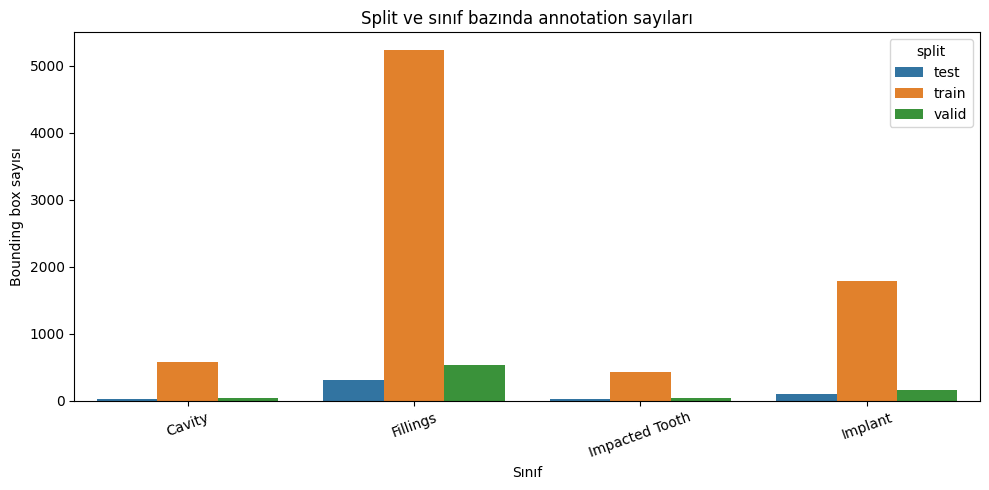

,object_count
count,1269.000000
mean,7.312845
std,4.853923
min,1.000000
25%,3.000000
50%,7.000000
75%,10.000000
max,26.000000


In [5]:
class_counts = (
    clean_df.groupby(["split", "class"])
    .size()
    .rename("count")
    .reset_index()
)

display(class_counts)

plt.figure(figsize=(10, 5))
sns.barplot(data=class_counts, x="class", y="count", hue="split")
plt.title("Split ve sınıf bazında annotation sayıları")
plt.xlabel("Sınıf")
plt.ylabel("Bounding box sayısı")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

objects_per_image = (
    clean_df.groupby(["split", "filename"])
    .size()
    .rename("object_count")
)

display(objects_per_image.describe().to_frame())

### 3.2 Veri sızıntısı kontrolü

Aynı dosya adının train, validation ve test split'lerinde bulunması veri sızıntısına yol açabilir.

In [6]:
split_names = {
    split: set(clean_df.loc[clean_df["split"].eq(split), "filename"])
    for split in ("train", "valid", "test")
}

print("Train–Valid ortak dosya:", len(split_names["train"] & split_names["valid"]))
print("Train–Test ortak dosya :", len(split_names["train"] & split_names["test"]))
print("Valid–Test ortak dosya :", len(split_names["valid"] & split_names["test"]))

Train–Valid ortak dosya: 0
Train–Test ortak dosya : 0
Valid–Test ortak dosya : 0


### 3.3 Örnek görüntüler ve gerçek kutular

Aşağıdaki hücre, annotation koordinatlarını görüntü üzerinde çizerek etiketlerin görsel olarak doğru yerde olup olmadığını kontrol eder.

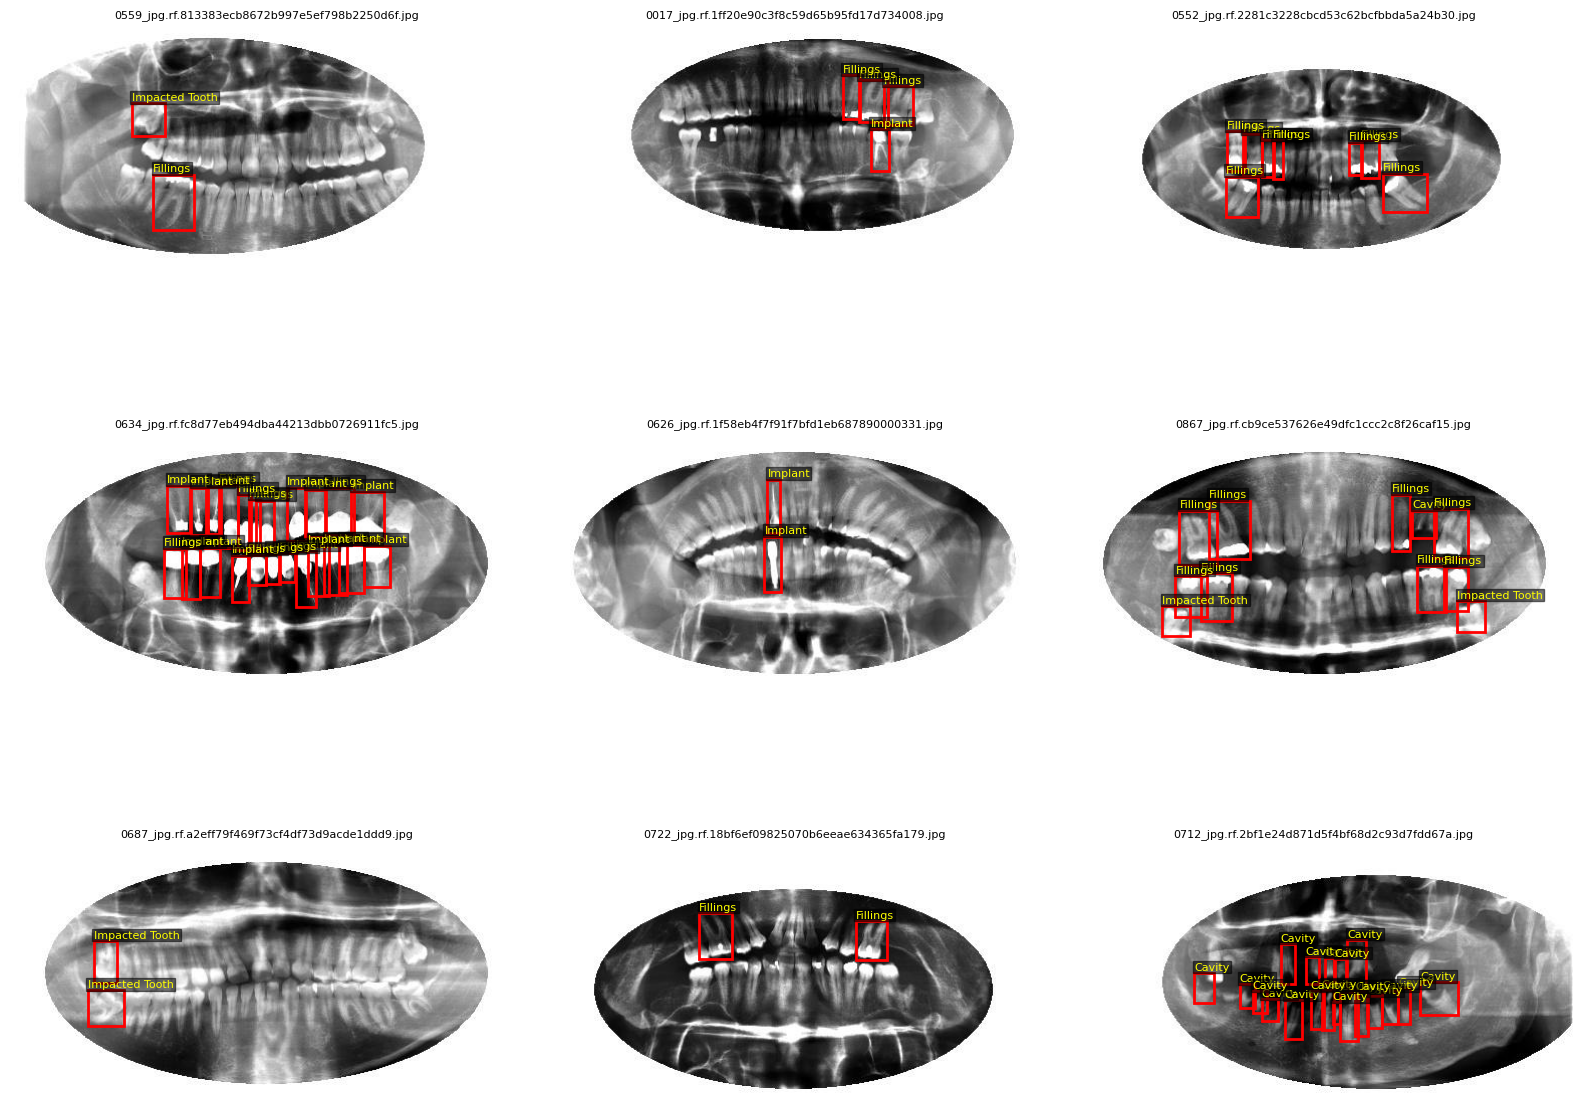

In [7]:
def show_annotated_samples(annotations: pd.DataFrame,image_dir: Path,sample_count: int = 9,seed: int = 42,) -> None:
    filenames = (
        annotations["filename"]
        .drop_duplicates()
        .sample(n=min(sample_count, annotations["filename"].nunique()), random_state=seed)
        .tolist()
    )

    cols = 3
    rows = int(np.ceil(len(filenames) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4.5 * rows), squeeze=False)
    axes = axes.flatten()

    for ax, filename in zip(axes, filenames):
        image = Image.open(image_dir / filename).convert("RGB")
        rows_df = annotations.loc[annotations["filename"].eq(filename)]

        ax.imshow(image)

        for _, row in rows_df.iterrows():
            width = row["xmax"] - row["xmin"]
            height = row["ymax"] - row["ymin"]

            ax.add_patch(
                Rectangle(
                    (row["xmin"], row["ymin"]),
                    width,
                    height,
                    fill=False,
                    linewidth=2,
                    edgecolor="red",
                )
            )
            ax.text(
                row["xmin"],
                max(0, row["ymin"] - 3),
                row["class"],
                fontsize=8,
                color="yellow",
                bbox={"facecolor": "black", "alpha": 0.55, "pad": 1},
            )

        ax.set_title(filename, fontsize=8)
        ax.axis("off")

    for ax in axes[len(filenames):]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


train_df = clean_df.loc[clean_df["split"].eq("train")].copy()
valid_df = clean_df.loc[clean_df["split"].eq("valid")].copy()
test_df = clean_df.loc[clean_df["split"].eq("test")].copy()

show_annotated_samples(train_df, DATA_ROOT / "train")

# Bölüm A — Custom ResNet50 Grid Detector

Bu bölümde YOLO benzeri temel bir fikir sıfırdan uygulanır:

1. ResNet50 görüntüden feature map üretir.
2. Görüntü `16 × 32` hücreli bir grid olarak temsil edilir.
3. Her hücre şu değerleri tahmin eder:
   - `objectness`
   - `cx, cy, width, height`
   - dört sınıf için logits

Model çıktısı dört sınıf için:

```text
[B, 5 + C, H, W] = [B, 9, 16, 32]
```

Bu yapı öğretici bir baseline'dır; modern detector'lardaki çok ölçekli feature fusion, gelişmiş target assignment ve standart mAP hattını içermez.

## 4. PyTorch Dataset ve dönüşümler

Detection augmentation uygulanırken görüntü ve bounding box aynı geometrik dönüşümü geçirmelidir. `torchvision.transforms.v2` ve `tv_tensors.BoundingBoxes` bunu birlikte yönetir.

Radyografilerde yoğunluk bilgisi önemli olduğu için agresif parlaklık/kontrast dönüşümleri varsayılan olarak kullanılmamıştır. Yalnızca yatay çevirme etkinleştirilmiştir.

In [8]:
class DentalRadiographyDataset(Dataset):
    def __init__(self,annotations: pd.DataFrame,image_dir: Path,transform=None):
        self.annotations = annotations.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.filenames = self.annotations["filename"].drop_duplicates().tolist()

        self.targets = {}
        for filename, group in self.annotations.groupby("filename", sort=False):
            self.targets[filename] = {
                "boxes": torch.tensor(
                    group[["xmin", "ymin", "xmax", "ymax"]].to_numpy(),
                    dtype=torch.float32,
                ),
                "labels": torch.tensor(
                    group["class_id"].to_numpy(),
                    dtype=torch.int64,
                ),
            }

    def __len__(self) -> int:
        return len(self.filenames)

    def __getitem__(self, index: int):
        filename = self.filenames[index]
        image = Image.open(self.image_dir / filename).convert("RGB")

        raw_target = self.targets[filename]
        target = {
            "boxes": tv_tensors.BoundingBoxes(
                raw_target["boxes"].clone(),
                format="XYXY",
                canvas_size=(image.height, image.width),
            ),
            "labels": raw_target["labels"].clone(),
        }

        if self.transform is not None:
            image, target = self.transform(image, target)

        return image, target


train_transforms = v2.Compose([
    v2.ToImage(),
    v2.RandomHorizontalFlip(p=0.5),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])

eval_transforms = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    ),
])

In [9]:
train_dataset = DentalRadiographyDataset(
    train_df,
    DATA_ROOT / "train",
    transform=train_transforms,
)
valid_dataset = DentalRadiographyDataset(
    valid_df,
    DATA_ROOT / "valid",
    transform=eval_transforms,
)
test_dataset = DentalRadiographyDataset(
    test_df,
    DATA_ROOT / "test",
    transform=eval_transforms,
)


def detection_collate_fn(batch):
    return tuple(zip(*batch))


CUSTOM_BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=CUSTOM_BATCH_SIZE,
    shuffle=True,
    collate_fn=detection_collate_fn,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=CUSTOM_BATCH_SIZE,
    shuffle=False,
    collate_fn=detection_collate_fn,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=CUSTOM_BATCH_SIZE,
    shuffle=False,
    collate_fn=detection_collate_fn,
)

images, targets = next(iter(train_loader))

print("Batch içindeki görüntü sayısı:", len(images))
print("İlk görüntü:", images[0].shape, images[0].dtype)
print("İlk target boxes:", targets[0]["boxes"].shape)
print("İlk target labels:", targets[0]["labels"].shape)

Batch içindeki görüntü sayısı: 8
İlk görüntü: torch.Size([3, 256, 512]) torch.float32
İlk target boxes: torch.Size([7, 4])
İlk target labels: torch.Size([7])


## 5. Custom model mimarisi

ResNet50'nin `layer3` çıktısı kullanılır. Böylece `256 × 512` giriş için yaklaşık `16 × 32` feature map elde edilir.

Detection head iki katmandan oluşur:

- `3 × 3 Conv`: komşu hücrelerden spatial bilgi toplar.
- `1 × 1 Conv`: özellikleri nihai objectness, box ve class çıktılarına dönüştürür.

İlk denemelerde yalnızca `1 × 1 Conv` kullanılmış; `3 × 3 Conv` eklenmesi kutu lokalizasyonunda belirgin iyileşme sağlamıştır.

In [10]:
class CustomGridDetector(nn.Module):
    def __init__(self, num_classes: int):
        super().__init__()

        resnet = resnet50(weights=ResNet50_Weights.DEFAULT)

     
        self.backbone = nn.Sequential(
            *list(resnet.children())[:-3]
        )

        self.head = nn.Sequential(
            nn.Conv2d(
                in_channels=1024,
                out_channels=256,
                kernel_size=3,
                padding=1,
            ),
            nn.ReLU(inplace=True),
            nn.Conv2d(
                in_channels=256,
                out_channels=5 + num_classes,
                kernel_size=1,
            ),
        )

    def forward(self, images: torch.Tensor) -> torch.Tensor:
        features = self.backbone(images)
        return self.head(features)


custom_model = CustomGridDetector(NUM_CLASSES)

dummy_input = torch.randn(2, 3, 256, 512)
dummy_output = custom_model(dummy_input)

print("Girdi :", tuple(dummy_input.shape))
print("Çıktı :", tuple(dummy_output.shape))
print("Kanallar: objectness + 4 box + 4 class =", 5 + NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 166MB/s] 


Girdi : (2, 3, 256, 512)
Çıktı : (2, 9, 16, 32)
Kanallar: objectness + 4 box + 4 class = 9


## 6. Target encoder

CSV'deki kutular `xmin, ymin, xmax, ymax` biçimindedir. Model ise grid üzerinde çalıştığı için target'lar şu tensorlara dönüştürülür:

- `objectness`: `[B, 1, H, W]`
- `boxes`: `[B, 4, H, W]`
- `labels`: `[B, H, W]`

Kutunun merkezinin düştüğü hücre o nesneden sorumlu tutulur.

> **Sınırlama:** Aynı grid hücresine iki nesne merkezi düşerse son nesne öncekinin target'ını üzerine yazar. Modern detector'lar daha gelişmiş target assignment kullanır.

In [11]:
def target_encoder(
    targets,
    image_height: int,
    image_width: int,
    grid_height: int,
    grid_width: int,
    device: torch.device,
):
    batch_size = len(targets)

    objectness_target = torch.zeros(
        (batch_size, 1, grid_height, grid_width),
        dtype=torch.float32,
        device=device,
    )

    box_target = torch.zeros(
        (batch_size, 4, grid_height, grid_width),
        dtype=torch.float32,
        device=device,
    )

    class_target = torch.full(
        (batch_size, grid_height, grid_width),
        fill_value=-1,
        dtype=torch.int64,
        device=device,
    )

    collision_count = 0

    for batch_index, target in enumerate(targets):
        boxes = target["boxes"].to(device)
        labels = target["labels"].to(device)

        for box, label in zip(boxes, labels):
            xmin, ymin, xmax, ymax = box

            cx = (xmin + xmax) / 2
            cy = (ymin + ymax) / 2
            box_width = xmax - xmin
            box_height = ymax - ymin

            cx_normalized = cx / image_width
            cy_normalized = cy / image_height
            width_normalized = box_width / image_width
            height_normalized = box_height / image_height

            grid_col = int((cx_normalized * grid_width).item())
            grid_row = int((cy_normalized * grid_height).item())

            grid_col = max(0, min(grid_col, grid_width - 1))
            grid_row = max(0, min(grid_row, grid_height - 1))

            if objectness_target[batch_index, 0, grid_row, grid_col].item() == 1.0:
                collision_count += 1

            objectness_target[batch_index, 0, grid_row, grid_col] = 1.0

            box_target[batch_index, :, grid_row, grid_col] = torch.stack([
                cx_normalized,
                cy_normalized,
                width_normalized,
                height_normalized,
            ])

            class_target[batch_index, grid_row, grid_col] = label

    return {
        "objectness": objectness_target,
        "boxes": box_target,
        "labels": class_target,
        "collision_count": collision_count,
    }

In [12]:
images, targets = next(iter(train_loader))
images_tensor = torch.stack(images)

with torch.no_grad():
    predictions = custom_model(images_tensor)

encoded_targets = target_encoder(
    targets=targets,
    image_height=images_tensor.shape[-2],
    image_width=images_tensor.shape[-1],
    grid_height=predictions.shape[-2],
    grid_width=predictions.shape[-1],
    device=predictions.device,
)

print("Prediction :", tuple(predictions.shape))
print("Objectness :", tuple(encoded_targets["objectness"].shape))
print("Boxes      :", tuple(encoded_targets["boxes"].shape))
print("Labels     :", tuple(encoded_targets["labels"].shape))
print("Bu batch'teki hücre çakışması:", encoded_targets["collision_count"])

Prediction : (8, 9, 16, 32)
Objectness : (8, 1, 16, 32)
Boxes      : (8, 4, 16, 32)
Labels     : (8, 16, 32)
Bu batch'teki hücre çakışması: 1


## 7. Loss fonksiyonu

Toplam loss üç parçadan oluşur:

1. **Objectness loss:** Hücrede nesne olup olmadığını öğrenir.
2. **Box loss:** Yalnızca pozitif hücrelerde `cx, cy, w, h` değerlerini karşılaştırır.
3. **Classification loss:** Yalnızca pozitif hücrelerde sınıfı öğrenir.

Bu baseline'da box regression için `Smooth L1` kullanılmıştır. Bu loss koordinat farklarını küçültür; ancak IoU'yu doğrudan optimize etmez.

In [13]:
def detection_loss(predictions, encoded_targets):
    objectness_logits = predictions[:, 0:1]
    box_predictions = predictions[:, 1:5]
    class_logits = predictions[:, 5:]

    objectness_true = encoded_targets["objectness"]
    box_true = encoded_targets["boxes"]
    class_true = encoded_targets["labels"]

    objectness_loss = F.binary_cross_entropy_with_logits(
        objectness_logits,
        objectness_true,
    )

    box_loss_map = F.smooth_l1_loss(
        torch.sigmoid(box_predictions),
        box_true,
        reduction="none",
    )

    box_mask = objectness_true.bool().expand_as(box_loss_map)

    if box_mask.any():
        box_loss = box_loss_map[box_mask].mean()
    else:
        box_loss = predictions.sum() * 0.0

    if (class_true != -1).any():
        class_loss = F.cross_entropy(
            class_logits,
            class_true,
            ignore_index=-1,
        )
    else:
        class_loss = predictions.sum() * 0.0

    total_loss = objectness_loss + box_loss + class_loss

    return {
        "total_loss": total_loss,
        "objectness_loss": objectness_loss,
        "box_loss": box_loss,
        "class_loss": class_loss,
    }

## 8. Custom model metrikleri

Bu evaluation fonksiyonu eğitim sürecini anlamak için şu ara metrikleri üretir:

- Objectness precision, recall ve F1
- Gerçek pozitif hücrelerde class accuracy
- Gerçek pozitif hücrelerde aynı indeksli kutuların ortalama IoU'su

> `class_accuracy`, modelin gerçek nesne hücresindeki sınıf tahminini ölçer. Bu nedenle tek başına uçtan uca detection classification başarısı değildir.
>
> `mean_box_iou`, standart mAP hesabı değildir. Tahminleri confidence sırasına göre eşleştirmez ve NMS uygulamaz.

In [14]:
def aligned_box_iou(
    pred_boxes: torch.Tensor,
    true_boxes: torch.Tensor,
) -> torch.Tensor:
    pred_xyxy = box_convert(
        pred_boxes,
        in_fmt="cxcywh",
        out_fmt="xyxy",
    ).clamp(0.0, 1.0)

    true_xyxy = box_convert(
        true_boxes,
        in_fmt="cxcywh",
        out_fmt="xyxy",
    ).clamp(0.0, 1.0)

    iou_matrix = box_iou(pred_xyxy, true_xyxy)
    return iou_matrix.diagonal()


@torch.no_grad()
def evaluate_custom_model(
    model,
    data_loader,
    device,
    num_classes: int,
    objectness_threshold: float = 0.5,
):
    model.eval()

    total_loss_metric = MeanMetric().to(device)
    objectness_loss_metric = MeanMetric().to(device)
    box_loss_metric = MeanMetric().to(device)
    class_loss_metric = MeanMetric().to(device)

    objectness_precision_metric = BinaryPrecision(
        threshold=objectness_threshold
    ).to(device)
    objectness_recall_metric = BinaryRecall(
        threshold=objectness_threshold
    ).to(device)
    objectness_f1_metric = BinaryF1Score(
        threshold=objectness_threshold
    ).to(device)

    class_accuracy_metric = MulticlassAccuracy(
        num_classes=num_classes,
        average="micro",
    ).to(device)

    mean_iou_metric = MeanMetric().to(device)

    class_sample_found = False
    box_sample_found = False

    for images, targets in data_loader:
        images = torch.stack(images).to(device)
        batch_size = images.shape[0]

        predictions = model(images)

        encoded_targets = target_encoder(
            targets=targets,
            image_height=images.shape[-2],
            image_width=images.shape[-1],
            grid_height=predictions.shape[-2],
            grid_width=predictions.shape[-1],
            device=device,
        )

        losses = detection_loss(predictions, encoded_targets)

        total_loss_metric.update(losses["total_loss"].detach(), weight=batch_size)
        objectness_loss_metric.update(
            losses["objectness_loss"].detach(),
            weight=batch_size,
        )
        box_loss_metric.update(losses["box_loss"].detach(), weight=batch_size)
        class_loss_metric.update(losses["class_loss"].detach(), weight=batch_size)

        objectness_logits = predictions[:, 0:1]
        box_predictions = predictions[:, 1:5]
        class_logits = predictions[:, 5:]

        objectness_true = encoded_targets["objectness"]
        box_true = encoded_targets["boxes"]
        class_true = encoded_targets["labels"]

        objectness_probabilities = torch.sigmoid(objectness_logits)
        objectness_targets = objectness_true.int()

        objectness_precision_metric.update(
            objectness_probabilities,
            objectness_targets,
        )
        objectness_recall_metric.update(
            objectness_probabilities,
            objectness_targets,
        )
        objectness_f1_metric.update(
            objectness_probabilities,
            objectness_targets,
        )

        predicted_classes = class_logits.argmax(dim=1)
        positive_class_mask = class_true != -1

        if positive_class_mask.any():
            class_accuracy_metric.update(
                predicted_classes[positive_class_mask],
                class_true[positive_class_mask],
            )
            class_sample_found = True

        positive_box_mask = objectness_true.squeeze(1).bool()

        predicted_box_grid = torch.sigmoid(
            box_predictions
        ).permute(0, 2, 3, 1)

        true_box_grid = box_true.permute(0, 2, 3, 1)

        if positive_box_mask.any():
            selected_pred_boxes = predicted_box_grid[positive_box_mask]
            selected_true_boxes = true_box_grid[positive_box_mask]

            ious = aligned_box_iou(
                selected_pred_boxes,
                selected_true_boxes,
            )

            mean_iou_metric.update(ious)
            box_sample_found = True

    return {
        "total_loss": total_loss_metric.compute().item(),
        "objectness_loss": objectness_loss_metric.compute().item(),
        "box_loss": box_loss_metric.compute().item(),
        "class_loss": class_loss_metric.compute().item(),
        "objectness_precision": objectness_precision_metric.compute().item(),
        "objectness_recall": objectness_recall_metric.compute().item(),
        "objectness_f1": objectness_f1_metric.compute().item(),
        "class_accuracy": (
            class_accuracy_metric.compute().item()
            if class_sample_found
            else 0.0
        ),
        "mean_box_iou": (
            mean_iou_metric.compute().item()
            if box_sample_found
            else 0.0
        ),
    }

## 9. Custom model eğitim döngüsü

Loss parçaları ayrı tutulur. Böylece toplam loss yükseldiğinde problemin objectness, box veya classification tarafından mı geldiği görülebilir.

Validation `mean_box_iou` iyileştiğinde model checkpoint'i kaydedilir.

In [15]:
def train_custom_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    device,
    epochs: int,
    num_classes: int,
    checkpoint_path: Path,
):
    history_rows = []
    best_box_iou = -1.0

    for epoch in range(1, epochs + 1):
        model.train()

        train_total_metric = MeanMetric().to(device)
        train_objectness_metric = MeanMetric().to(device)
        train_box_metric = MeanMetric().to(device)
        train_class_metric = MeanMetric().to(device)

        for images, targets in train_loader:
            images = torch.stack(images).to(device)
            batch_size = images.shape[0]

            optimizer.zero_grad(set_to_none=True)

            predictions = model(images)

            encoded_targets = target_encoder(
                targets=targets,
                image_height=images.shape[-2],
                image_width=images.shape[-1],
                grid_height=predictions.shape[-2],
                grid_width=predictions.shape[-1],
                device=device,
            )

            losses = detection_loss(predictions, encoded_targets)
            losses["total_loss"].backward()
            optimizer.step()

            train_total_metric.update(
                losses["total_loss"].detach(),
                weight=batch_size,
            )
            train_objectness_metric.update(
                losses["objectness_loss"].detach(),
                weight=batch_size,
            )
            train_box_metric.update(
                losses["box_loss"].detach(),
                weight=batch_size,
            )
            train_class_metric.update(
                losses["class_loss"].detach(),
                weight=batch_size,
            )

        train_metrics = {
            "train_total_loss": train_total_metric.compute().item(),
            "train_objectness_loss": train_objectness_metric.compute().item(),
            "train_box_loss": train_box_metric.compute().item(),
            "train_class_loss": train_class_metric.compute().item(),
        }

        val_metrics = evaluate_custom_model(
            model=model,
            data_loader=val_loader,
            device=device,
            num_classes=num_classes,
            objectness_threshold=0.5,
        )

        row = {
            "epoch": epoch,
            **train_metrics,
            **{f"val_{key}": value for key, value in val_metrics.items()},
        }
        history_rows.append(row)

        if val_metrics["mean_box_iou"] > best_box_iou:
            best_box_iou = val_metrics["mean_box_iou"]
            checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save(model.state_dict(), checkpoint_path)

        print(
            f"Epoch [{epoch}/{epochs}]\n"
            f"Train | Total: {train_metrics['train_total_loss']:.4f} | "
            f"Obj: {train_metrics['train_objectness_loss']:.4f} | "
            f"Box: {train_metrics['train_box_loss']:.6f} | "
            f"Class: {train_metrics['train_class_loss']:.4f}\n"
            f"Val   | Total: {val_metrics['total_loss']:.4f} | "
            f"Obj: {val_metrics['objectness_loss']:.4f} | "
            f"Box: {val_metrics['box_loss']:.6f} | "
            f"Class: {val_metrics['class_loss']:.4f}\n"
            f"Metrics | Obj P: {val_metrics['objectness_precision']:.3f} | "
            f"Obj R: {val_metrics['objectness_recall']:.3f} | "
            f"Obj F1: {val_metrics['objectness_f1']:.3f} | "
            f"Class Acc: {val_metrics['class_accuracy']:.3f} | "
            f"Box IoU: {val_metrics['mean_box_iou']:.3f}"
        )

    return pd.DataFrame(history_rows)

In [16]:
RUN_CUSTOM_TRAINING = False
CUSTOM_EPOCHS = 20
CUSTOM_CHECKPOINT = WORK_ROOT / "custom_grid_detector_best.pt"

custom_model = CustomGridDetector(NUM_CLASSES).to(DEVICE)
custom_optimizer = torch.optim.Adam(
    custom_model.parameters(),
    lr=1e-4,
)

if RUN_CUSTOM_TRAINING:
    custom_history = train_custom_model(
        model=custom_model,
        train_loader=train_loader,
        val_loader=valid_loader,
        optimizer=custom_optimizer,
        device=DEVICE,
        epochs=CUSTOM_EPOCHS,
        num_classes=NUM_CLASSES,
        checkpoint_path=CUSTOM_CHECKPOINT,
    )

    custom_history.to_csv(
        WORK_ROOT / "custom_grid_detector_history.csv",
        index=False,
    )
    display(custom_history.tail())
else:
    print(
        "Custom modeli yeniden eğitmek için "
        "RUN_CUSTOM_TRAINING = True yapın."
    )

Custom modeli yeniden eğitmek için RUN_CUSTOM_TRAINING = True yapın.


### Kaydedilmiş custom model gözlemleri

Bu notebook'un önceki koşularında:

- Feature map'i `8 × 16`'dan `16 × 32`'ye çıkarmak tek başına küçük bir iyileşme sağladı.
- Head'e `3 × 3 Conv` eklemek lokalizasyonu daha hızlı ve daha iyi öğrenmesini sağladı.
- Son custom koşulda validation `mean aligned box IoU` yaklaşık **0.147** seviyesine ulaştı.
- Kaydedilmiş test sonucunda objectness F1 yaklaşık **0.632**, class accuracy yaklaşık **0.970** ve mean aligned box IoU yaklaşık **0.106** oldu.

Bu sonuçlar custom detector'ın sınıf ve objectness tarafını öğrenebildiğini; ancak kutu lokalizasyonunun ana darboğaz olarak kaldığını gösterir.

# Bölüm B — YOLO26s

Custom model detection'ın temel bileşenlerini anlamak için yararlıdır. Performans odaklı ikinci yaklaşımda, pretrained ve çok ölçekli bir YOLO detector kullanılır.

Ultralytics YOLO eğitimi CSV annotation dosyasını doğrudan kullanmaz. Her görüntü için aynı isimde bir `.txt` dosyası hazırlanır:

```text
class_id x_center y_center width height
```

Koordinatlar `0–1` aralığına normalize edilir.

## 10. CSV annotation'larını YOLO formatına dönüştürme

Dönüşüm `/kaggle/working/Yolo_format` altında yeni bir veri seti üretir; orijinal Kaggle input verisini değiştirmez.

In [17]:
SPLIT_MAPPING = {
    "train": "train",
    "valid": "val",
    "test": "test",
}


def convert_split_to_yolo(
    source_root: Path,
    output_root: Path,
    source_split: str,
    target_split: str,
):
    csv_path = source_root / source_split / "_annotations.csv"
    source_image_dir = source_root / source_split

    target_image_dir = output_root / "images" / target_split
    target_label_dir = output_root / "labels" / target_split

    target_image_dir.mkdir(parents=True, exist_ok=True)
    target_label_dir.mkdir(parents=True, exist_ok=True)

    split_df = pd.read_csv(csv_path).rename(
        columns={"class": "class_name"}
    )

    required_columns = {
        "filename", "width", "height", "class_name",
        "xmin", "ymin", "xmax", "ymax",
    }
    missing_columns = required_columns - set(split_df.columns)

    if missing_columns:
        raise ValueError(
            f"{csv_path} içinde eksik sütunlar var: {missing_columns}"
        )

    unknown_classes = (
        set(split_df["class_name"].dropna().unique())
        - set(CLASS_TO_ID)
    )
    if unknown_classes:
        raise ValueError(f"Bilinmeyen sınıflar: {unknown_classes}")

    converted_images = 0
    converted_boxes = 0
    skipped_boxes = 0

    for filename, image_rows in split_df.groupby("filename", sort=False):
        source_image_path = source_image_dir / filename
        target_image_path = target_image_dir / filename

        if not source_image_path.exists():
            print("Eksik görüntü:", source_image_path)
            continue

        shutil.copy2(source_image_path, target_image_path)

        label_lines = []

        for row in image_rows.itertuples(index=False):
            image_width = float(row.width)
            image_height = float(row.height)

            xmin = float(np.clip(row.xmin, 0, image_width))
            ymin = float(np.clip(row.ymin, 0, image_height))
            xmax = float(np.clip(row.xmax, 0, image_width))
            ymax = float(np.clip(row.ymax, 0, image_height))

            box_width = xmax - xmin
            box_height = ymax - ymin

            if box_width <= 0 or box_height <= 0:
                skipped_boxes += 1
                continue

            center_x = (xmin + xmax) / 2.0
            center_y = (ymin + ymax) / 2.0
            class_id = CLASS_TO_ID[row.class_name]

            label_lines.append(
                f"{class_id} "
                f"{center_x / image_width:.6f} "
                f"{center_y / image_height:.6f} "
                f"{box_width / image_width:.6f} "
                f"{box_height / image_height:.6f}"
            )
            converted_boxes += 1

        label_path = target_label_dir / f"{Path(filename).stem}.txt"
        label_path.write_text(
            "\n".join(label_lines),
            encoding="utf-8",
        )
        converted_images += 1

    return {
        "source_split": source_split,
        "target_split": target_split,
        "images": converted_images,
        "boxes": converted_boxes,
        "skipped_boxes": skipped_boxes,
    }


REBUILD_YOLO_DATASET = True

if REBUILD_YOLO_DATASET and YOLO_ROOT.exists():
    shutil.rmtree(YOLO_ROOT)

conversion_results = []

for source_split, target_split in SPLIT_MAPPING.items():
    conversion_results.append(
        convert_split_to_yolo(
            source_root=DATA_ROOT,
            output_root=YOLO_ROOT,
            source_split=source_split,
            target_split=target_split,
        )
    )

display(pd.DataFrame(conversion_results))

,source_split,target_split,images,boxes,skipped_boxes
0,train,train,1075,8027,3
1,valid,val,121,780,0
2,test,test,73,473,0


## 11. `data.yaml` oluşturma ve veri yapısını doğrulama

YAML dosyası kutuları içermez. Yalnızca veri setinin kökünü, split yollarını ve sınıf adlarını tanımlar.

In [18]:
data_yaml = {
    "path": str(YOLO_ROOT),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": ID_TO_CLASS,
}

yaml_path = YOLO_ROOT / "data.yaml"

with yaml_path.open("w", encoding="utf-8") as file:
    yaml.safe_dump(
        data_yaml,
        file,
        sort_keys=False,
        allow_unicode=True,
    )

print(yaml_path.read_text(encoding="utf-8"))

file_count_rows = []
for split in ("train", "val", "test"):
    image_count = len(list((YOLO_ROOT / "images" / split).glob("*.*")))
    label_count = len(list((YOLO_ROOT / "labels" / split).glob("*.txt")))

    file_count_rows.append({
        "split": split,
        "images": image_count,
        "labels": label_count,
    })

display(pd.DataFrame(file_count_rows))

path: /kaggle/working/Yolo_format
train: images/train
val: images/val
test: images/test
names:
  0: Cavity
  1: Fillings
  2: Impacted Tooth
  3: Implant



,split,images,labels
0,train,1075,1075
1,val,121,121
2,test,73,73


In [21]:
from ultralytics.data.utils import check_det_dataset

dataset_info = check_det_dataset(str(yaml_path))
print("YOLO veri seti doğrulandı.")
print("Train path:", dataset_info["train"])
print("Val path  :", dataset_info["val"])
print("Test path :", dataset_info.get("test"))

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO veri seti doğrulandı.
Train path: /kaggle/working/Yolo_format/images/train
Val path  : /kaggle/working/Yolo_format/images/val
Test path : /kaggle/working/Yolo_format/images/test


## 12. YOLO26s eğitimi

Bu koşuda:

- Model: `yolo26s.pt`
- Input size: `1280`
- Epoch üst sınırı: `50`
- Early stopping patience: `10`
- Batch: `8`

Önceki denemede `batch=16`, Tesla T4 belleğine sığmadığı için otomatik olarak `8`'e düşürülmüştür. Final kodda doğrudan `8` kullanılır.

In [ ]:
from ultralytics import YOLO

RUN_YOLO_TRAINING = False
YOLO_RUN_NAME = "dental_yolo26s"
YOLO_PROJECT = WORK_ROOT / "runs"

if RUN_YOLO_TRAINING:
    yolo_model = YOLO("yolo26s.pt")

    yolo_train_results = yolo_model.train(
        data=str(yaml_path),
        epochs=50,
        imgsz=1280,
        batch=8,
        patience=10,
        project=str(YOLO_PROJECT),
        name=YOLO_RUN_NAME,
        exist_ok=True,
        seed=SEED,
    )
else:
    print(
        "YOLO'yu yeniden eğitmek için "
        "RUN_YOLO_TRAINING = True yapın."
    )

### Kaydedilmiş YOLO eğitim sonucu

Önceki koşu early stopping ile **43. epoch'ta** durmuştur. En iyi sonuç **33. epoch'ta** elde edilmiş ve `best.pt` olarak kaydedilmiştir.

Final validation özetinde:

- Precision: **0.829**
- Recall: **0.730**
- mAP50: **0.811**
- mAP50-95: **0.554**

elde edilmiştir.

## 13. En iyi YOLO modelini validation setinde değerlendirme

`last.pt` son epoch'u; `best.pt` ise validation metriğine göre en iyi checkpoint'i temsil eder. Nihai değerlendirmede `best.pt` kullanılır.

In [ ]:
from ultralytics import YOLO

BEST_MODEL_PATH = (
    YOLO_PROJECT
    / YOLO_RUN_NAME
    / "weights"
    / "best.pt"
)

if not BEST_MODEL_PATH.exists():
    raise FileNotFoundError(
        f"best.pt bulunamadı: {BEST_MODEL_PATH}\n"
        "Önce YOLO eğitimini çalıştırın veya doğru yolu girin."
    )

best_yolo_model = YOLO(str(BEST_MODEL_PATH))

val_metrics = best_yolo_model.val(
    data=str(yaml_path),
    split="val",
    imgsz=1280,
    batch=8,
    plots=True,
    save_json=True,
    project=str(YOLO_PROJECT),
    name="dental_yolo26s_final_val",
    exist_ok=True,
)

### 13.1 Genel detection metrikleri

- **Precision:** Modelin ürettiği tahminlerin ne kadarı doğru?
- **Recall:** Gerçek nesnelerin ne kadarı bulundu?
- **F1:** Precision ve recall dengesi.
- **mAP50:** IoU eşiği 0.50 iken ortalama AP.
- **mAP75:** Daha sıkı lokalizasyon eşiği.
- **mAP50-95:** IoU 0.50–0.95 aralığındaki AP değerlerinin ortalaması.

In [ ]:
mean_precision = float(val_metrics.box.mp)
mean_recall = float(val_metrics.box.mr)
mean_f1 = (
    2 * mean_precision * mean_recall
    / max(mean_precision + mean_recall, 1e-12)
)

general_val_metrics = pd.Series({
    "Precision": mean_precision,
    "Recall": mean_recall,
    "F1": mean_f1,
    "mAP@0.50": float(val_metrics.box.map50),
    "mAP@0.75": float(val_metrics.box.map75),
    "mAP@0.50:0.95": float(val_metrics.box.map),
}, name="validation")

display(general_val_metrics.to_frame().round(4))

### 13.2 Sınıf bazlı metrikler

Veri dengesiz olduğu için genel ortalama tek başına yeterli değildir. Özellikle `Cavity` recall değeri ayrı izlenmelidir.

In [ ]:
class_metric_rows = []

for metric_index, class_id in enumerate(val_metrics.box.ap_class_index):
    class_id = int(class_id)

    precision = float(val_metrics.box.p[metric_index])
    recall = float(val_metrics.box.r[metric_index])
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    class_metric_rows.append({
        "class_id": class_id,
        "class_name": best_yolo_model.names[class_id],
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "AP50": float(val_metrics.box.ap50[metric_index]),
        "AP50-95": float(val_metrics.box.ap[metric_index]),
    })

class_metrics_df = pd.DataFrame(class_metric_rows)
display(class_metrics_df.round(4))

class_metrics_df.to_csv(
    WORK_ROOT / "yolo_validation_class_metrics.csv",
    index=False,
)

Kaydedilmiş validation koşusunda sınıf bazlı sonuçlar:

| Sınıf | Precision | Recall | AP50 | AP50-95 |
|---|---:|---:|---:|---:|
| Cavity | 0.774 | 0.419 | 0.576 | 0.363 |
| Fillings | 0.877 | 0.869 | 0.921 | 0.620 |
| Impacted Tooth | 0.740 | 0.684 | 0.778 | 0.562 |
| Implant | 0.927 | 0.950 | 0.970 | 0.669 |

Ana zayıflık `Cavity` sınıfının recall değeridir. Model cavity tahmin ettiğinde çoğunlukla doğru olsa da gerçek cavity örneklerinin önemli bir bölümünü kaçırmaktadır.

### 13.3 Confusion matrix

Detection confusion matrix'inde background satırı/sütunu kaçırılan gerçek nesneleri ve yanlış pozitif tahminleri gösterir.

In [ ]:
confusion_matrix = val_metrics.confusion_matrix.matrix

class_names = [
    best_yolo_model.names[index]
    for index in range(len(best_yolo_model.names))
]
matrix_names = class_names + ["background"]

confusion_df = pd.DataFrame(
    confusion_matrix,
    index=[f"pred_{name}" for name in matrix_names],
    columns=[f"true_{name}" for name in matrix_names],
)

display(confusion_df)

plt.figure(figsize=(9, 7))
sns.heatmap(confusion_df, annot=True, fmt=".0f", cmap="Blues")
plt.title("YOLO Validation Confusion Matrix")
plt.xlabel("Gerçek")
plt.ylabel("Tahmin")
plt.tight_layout()
plt.show()

### 13.4 Hız metrikleri

In [ ]:
speed_df = pd.Series(
    val_metrics.speed,
    name="ms_per_image",
).to_frame()

display(speed_df.round(3))

### 13.5 Ultralytics'in ürettiği rapor görselleri

`plots=True` ile precision-recall eğrileri, F1 eğrisi, confusion matrix ve örnek tahmin görselleri kaydedilir.

In [ ]:
from IPython.display import display as ipy_display

result_dir = Path(val_metrics.save_dir)

report_files = [
    "BoxPR_curve.png",
    "BoxF1_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "val_batch0_labels.jpg",
    "val_batch0_pred.jpg",
]

for filename in report_files:
    file_path = result_dir / filename

    if file_path.exists():
        print(filename)
        ipy_display(Image.open(file_path))
    else:
        print("Bulunamadı:", filename)

## 14. Final test değerlendirmesi

Model ve hiperparametre kararları validation setine göre verilir. Test seti bütün kararlar tamamlandıktan sonra yalnızca nihai rapor için kullanılır.

In [ ]:
test_metrics = best_yolo_model.val(
    data=str(yaml_path),
    split="test",
    imgsz=1280,
    batch=8,
    plots=True,
    project=str(YOLO_PROJECT),
    name="dental_yolo26s_final_test",
    exist_ok=True,
)

test_precision = float(test_metrics.box.mp)
test_recall = float(test_metrics.box.mr)
test_f1 = (
    2 * test_precision * test_recall
    / max(test_precision + test_recall, 1e-12)
)

general_test_metrics = pd.Series({
    "Precision": test_precision,
    "Recall": test_recall,
    "F1": test_f1,
    "mAP@0.50": float(test_metrics.box.map50),
    "mAP@0.75": float(test_metrics.box.map75),
    "mAP@0.50:0.95": float(test_metrics.box.map),
}, name="test")

display(general_test_metrics.to_frame().round(4))

## 15. Örnek YOLO tahminleri

Aşağıdaki hücre test setinden birkaç görüntü seçer ve model tahminlerini gösterir.

In [ ]:
test_image_paths = sorted(
    (YOLO_ROOT / "images" / "test").glob("*.*")
)

sample_paths = random.Random(SEED).sample(
    test_image_paths,
    k=min(6, len(test_image_paths)),
)

prediction_results = best_yolo_model.predict(
    source=[str(path) for path in sample_paths],
    imgsz=1280,
    conf=0.25,
    save=False,
    verbose=False,
)

fig, axes = plt.subplots(
    nrows=len(prediction_results),
    ncols=1,
    figsize=(16, 5 * len(prediction_results)),
)

if len(prediction_results) == 1:
    axes = [axes]

for ax, result in zip(axes, prediction_results):
    plotted = result.plot()
    plotted_rgb = plotted[..., ::-1]
    ax.imshow(plotted_rgb)
    ax.set_title(Path(result.path).name)
    ax.axis("off")

plt.tight_layout()
plt.show()

# 16. Custom detector ve YOLO26s karşılaştırması

| Özellik | Custom ResNet grid detector | YOLO26s |
|---|---|---|
| Backbone | ResNet50 `layer3` | YOLO26s pretrained backbone |
| Feature scale | Tek ölçek (`16 × 32`) | Çok ölçekli feature map |
| Head | `3 × 3 Conv + 1 × 1 Conv` | Gelişmiş çok ölçekli Detect head |
| Hücre/target atama | Merkez hücresi, hücre başına tek target | Gelişmiş detection target assignment |
| Box loss | Smooth L1 | Gelişmiş detection box/lokalizasyon loss'ları |
| Değerlendirme | Ara objectness/class/IoU metrikleri | Standart precision, recall ve mAP |
| Kullanım amacı | Öğrenme ve baseline | Performans ve üretim adayı |

### Sonuçların yorumu

Custom model, objectness ve sınıflandırma tarafını öğrenebilmiş; fakat tek ölçekli yapı, basit target encoding ve Smooth L1 box loss nedeniyle lokalizasyon sınırlı kalmıştır.

YOLO26s validation setinde yaklaşık:

- Precision: **0.829**
- Recall: **0.730**
- F1: **0.766**
- mAP50: **0.811**
- mAP75: **0.658**
- mAP50-95: **0.554**

elde etmiştir.

Bu sonuç, hazır detector'ın yalnızca daha büyük olmasından değil; çok ölçekli özellik çıkarımı, daha gelişmiş detection head'i, target assignment ve standart eğitim/değerlendirme hattından faydalanmasından kaynaklanır.

# 17. Sınırlamalar ve sonraki adımlar

1. `Cavity` sınıfının recall değeri düşüktür. Öncelik annotation kalitesini ve azınlık sınıf örneklerini incelemektir.
2. Sınıf bazlı hata analizi yapılmalı; kaçırılan cavity örnekleri görsel olarak incelenmelidir.
3. Küçük nesneler için yüksek çözünürlük korunabilir; gerekirse crop/tiling yaklaşımı ayrı deney olarak denenebilir.
4. Augmentation türleri radyografi doğasına uygun ve kontrollü seçilmelidir.
5. Nihai raporda validation ve test sonuçları kesin biçimde ayrılmalıdır.
6. Model klinik kullanım için değerlendirilmemiştir; bu çalışma veri bilimi ve object detection deneyi niteliğindedir.